# Loading Libraries

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Importing the data

In [ ]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import PROCESSED_DATA_DIR

import pandas as pd

# Load the data
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test_processed.csv")

# Split Features and Target

In [4]:
X_train = train_df.drop(columns="Diabetes_binary")
y_train = train_df["Diabetes_binary"]

X_test = test_df.drop(columns="Diabetes_binary")
y_test = test_df["Diabetes_binary"]

# Function to Evaluate the Model

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name=''):
    # Train predictions
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds, average='binary')  # or 'macro' for multi-class
    train_cf = confusion_matrix(y_train, train_preds, normalize='true')
    
    # Test predictions
    test_preds = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds, average='binary')
    test_cf = confusion_matrix(y_test, test_preds, normalize='true')
    
    # Print accuracy and recall
    print(f"{name} Accuracy:")
    print(f"  Train: {train_accuracy * 100:.2f}%")
    print(f"  Test : {test_accuracy * 100:.2f}%")
    print(f"{name} Recall:")
    print(f"  Train: {train_recall * 100:.2f}%")
    print(f"  Test : {test_recall * 100:.2f}%")

    # Print classification report (includes recall too)
    print(f"\n{name} Classification Report (Test):")
    print(classification_report(y_test, test_preds))

    # Plot confusion matrices
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(train_cf, annot=True, ax=axs[0], cmap='Blues')
    axs[0].set_title(f"{name} - Train Confusion Matrix")
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    sns.heatmap(test_cf, annot=True, ax=axs[1], cmap='Greens')
    axs[1].set_title(f"{name} - Test Confusion Matrix")
    axs[1].set_xlabel('Predicted')
    axs[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# Random Forest Classifier

Random Forest Accuracy:
  Train: 96.46%
  Test : 72.09%
Random Forest Recall:
  Train: 96.08%
  Test : 74.99%

Random Forest Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.72      0.69      0.71      6723
         1.0       0.72      0.75      0.73      7089

    accuracy                           0.72     13812
   macro avg       0.72      0.72      0.72     13812
weighted avg       0.72      0.72      0.72     13812



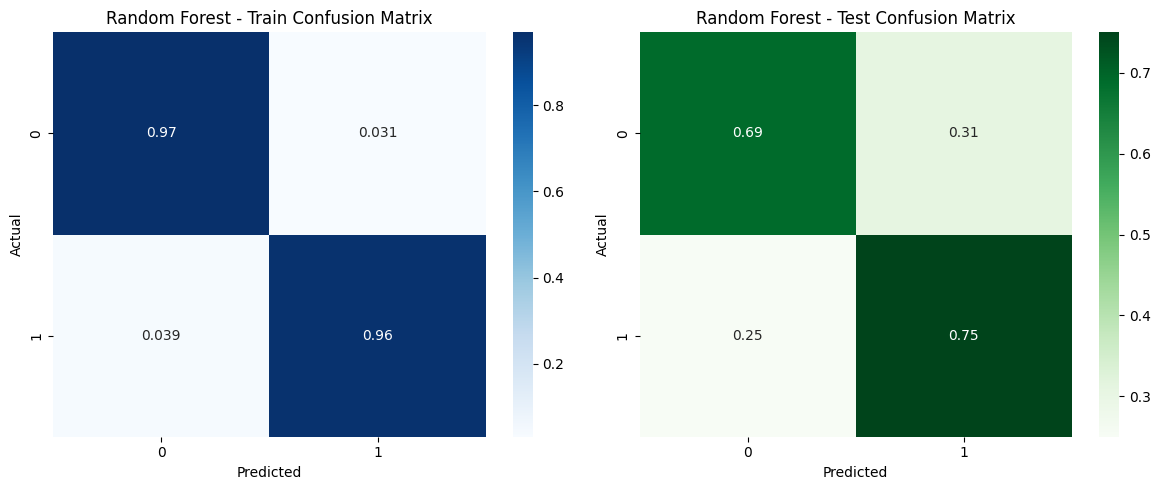

In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_train, y_train, X_test, y_test, name='Random Forest')

# Random Forest Classifier Tuned

Fitting 2 folds for each of 225 candidates, totalling 450 fits
Best Parameters for RF: {'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 15, 'n_estimators': 30}
Tuned Random Forest Accuracy:
  Train: 74.52%
  Test : 74.90%
Tuned Random Forest Recall:
  Train: 79.15%
  Test : 79.16%

Tuned Random Forest Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73      6723
         1.0       0.74      0.79      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



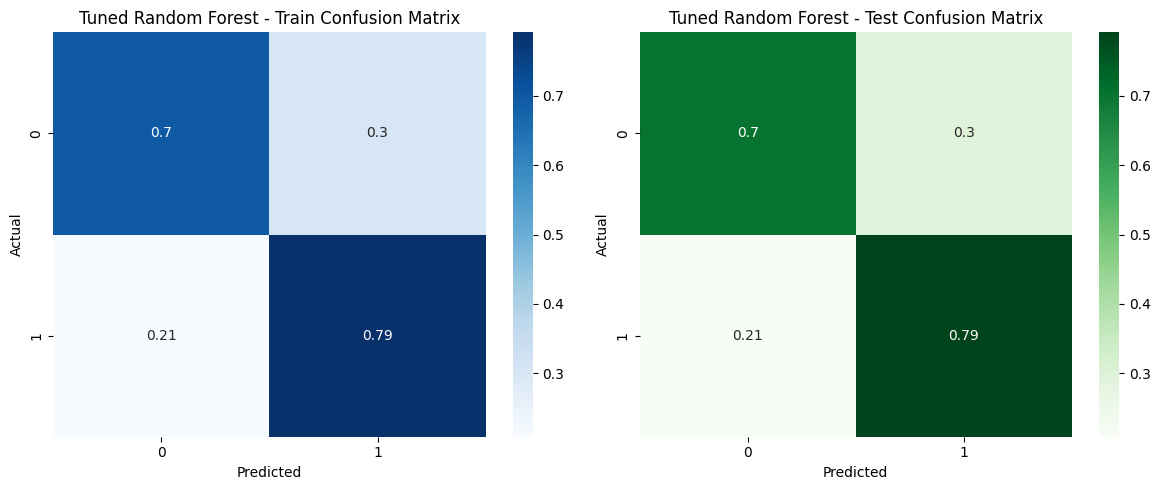

In [8]:
param_grid_rf = {
    'n_estimators': [10, 20, 30], 
    'max_depth': [10, 20, 30], 
    'min_samples_split': [2, 5, 10, 15, 20], 
    'min_samples_leaf': [1, 2, 4, 6, 8]  
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=2,
    scoring='recall',
    n_jobs=1, 
    verbose=1
)

# Subset the training data for hyperparameter tuning
# Using a smaller subset to speed up the grid search process
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.2, stratify=y_train, random_state=42)
grid_rf.fit(X_sub, y_sub)

print("Best Parameters for RF:", grid_rf.best_params_)
evaluate_model(grid_rf.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned Random Forest")

# XGBoost

XGBoost Accuracy:
  Train: 76.92%
  Test : 75.20%
XGBoost Recall:
  Train: 81.62%
  Test : 79.22%

XGBoost Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.76      0.71      0.74      6723
         1.0       0.74      0.79      0.77      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



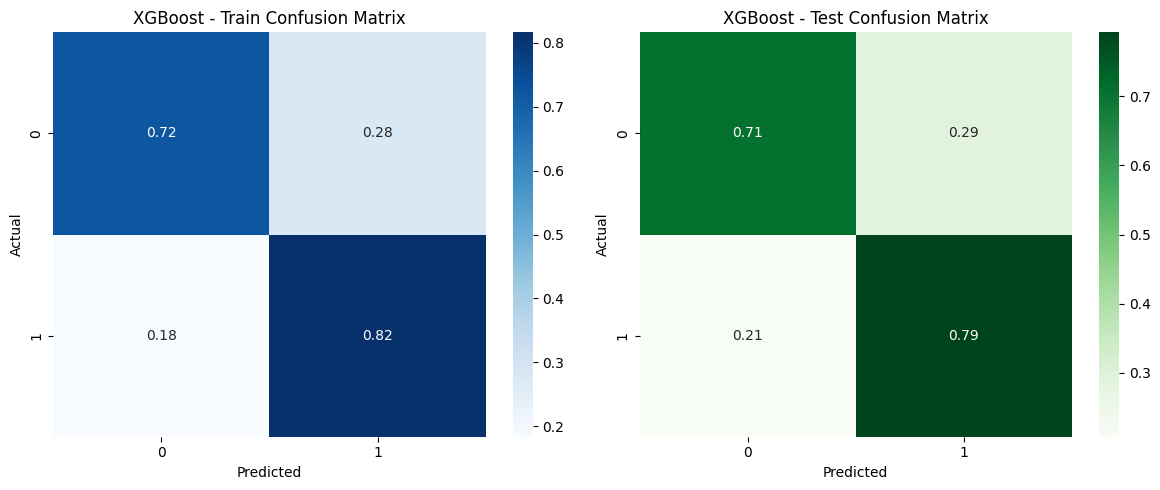

In [9]:
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
evaluate_model(xgb, X_train, y_train, X_test, y_test, name='XGBoost')

# XGBoost Tuned

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best Parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}
Tuned XGBoost Accuracy:
  Train: 73.09%
  Test : 73.60%
Tuned XGBoost Recall:
  Train: 80.39%
  Test : 80.49%

Tuned XGBoost Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.76      0.66      0.71      6723
         1.0       0.72      0.80      0.76      7089

    accuracy                           0.74     13812
   macro avg       0.74      0.73      0.73     13812
weighted avg       0.74      0.74      0.73     13812



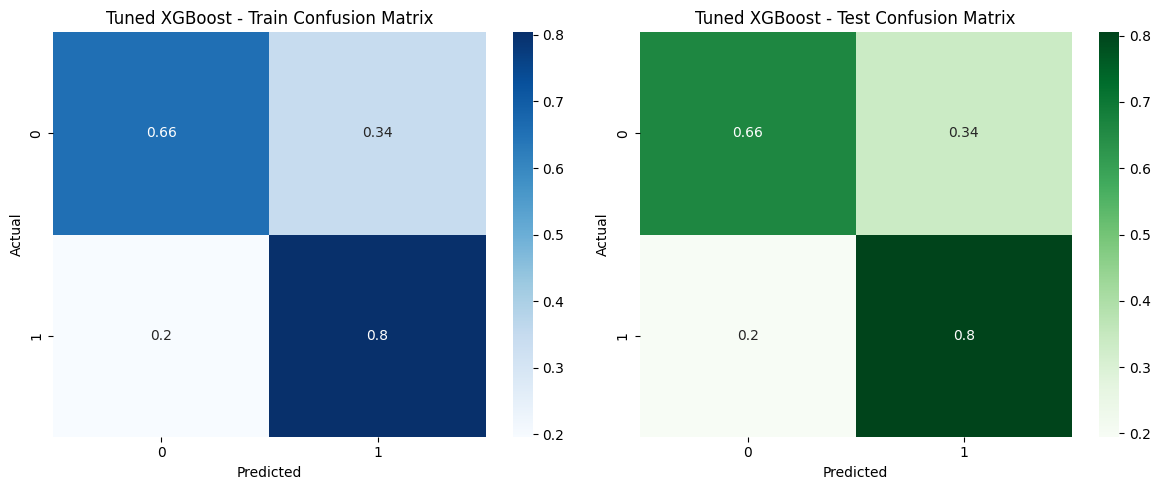

In [10]:
param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}
# Using a small portion of the training data
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.2, stratify=y_train, random_state=42)
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=4,                 
    scoring='recall',
    n_jobs=1,             
    verbose=1,
    random_state=42
)

random_search_xgb.fit(X_sub, y_sub)

print("Best Parameters for XGBoost:", random_search_xgb.best_params_)
evaluate_model(random_search_xgb.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned XGBoost")


# K-Nearest Neighbors

KNN Accuracy:
  Train: 79.22%
  Test : 71.17%
KNN Recall:
  Train: 81.97%
  Test : 73.04%

KNN Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.71      0.69      0.70      6723
         1.0       0.71      0.73      0.72      7089

    accuracy                           0.71     13812
   macro avg       0.71      0.71      0.71     13812
weighted avg       0.71      0.71      0.71     13812



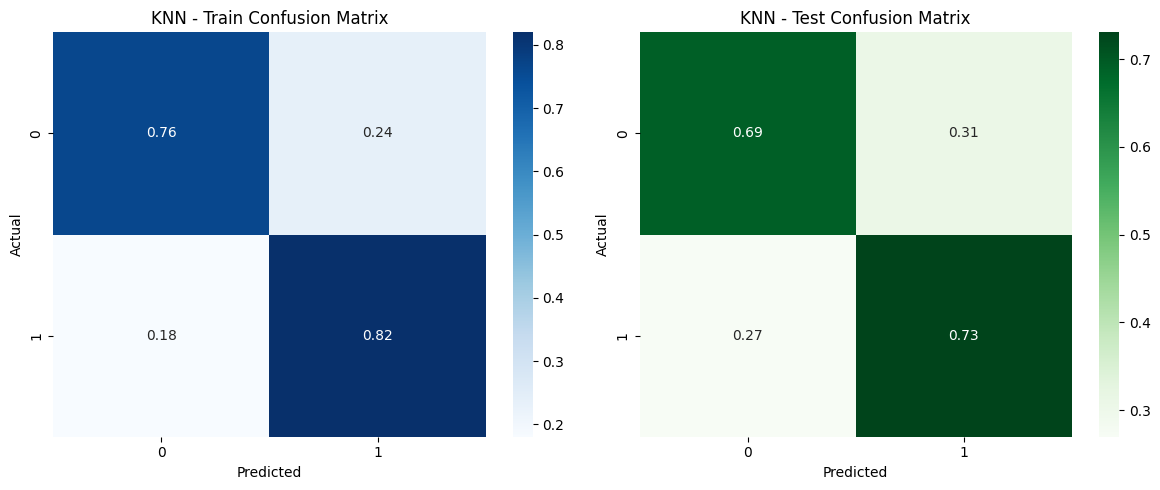

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
evaluate_model(knn, X_train, y_train, X_test, y_test, name='KNN')

# Knn Tuned

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Tuned KNN Accuracy:
  Train: 77.10%
  Test : 72.55%
Tuned KNN Recall:
  Train: 80.66%
  Test : 75.71%

Tuned KNN Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.73      0.69      0.71      6723
         1.0       0.72      0.76      0.74      7089

    accuracy                           0.73     13812
   macro avg       0.73      0.72      0.72     13812
weighted avg       0.73      0.73      0.73     13812



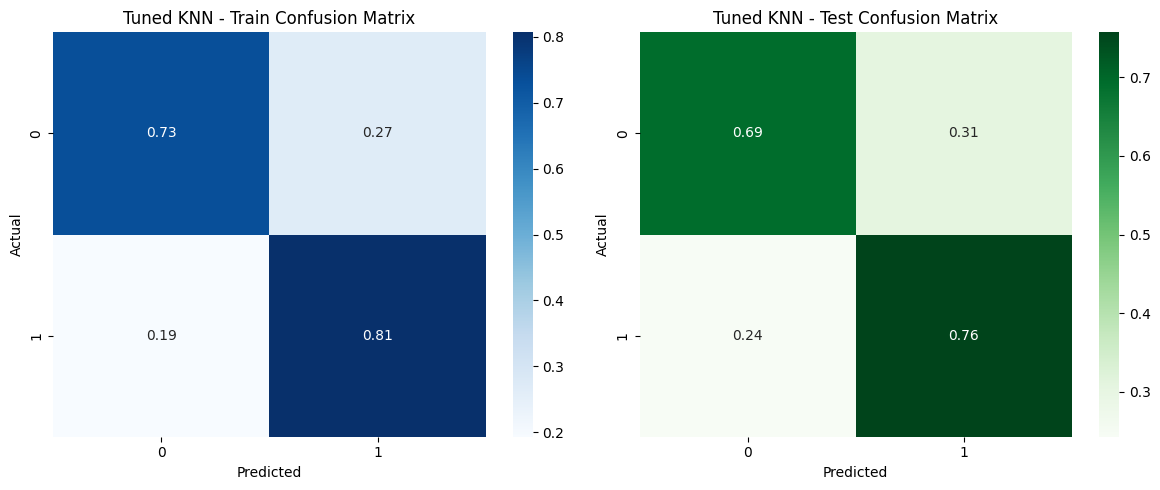

In [12]:
param_grid_knn = {
    'n_neighbors': list(range(3, 11)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, 
                        cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

print("Best Parameters for KNN:", grid_knn.best_params_)
evaluate_model(grid_knn.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned KNN")

# Evaluation

| Models | Training Recall | Test Recall|
|--------|-------------------|--------------|
|Random Forest Classifier|96.08%|74.99%|
|Random Forest Classifier (Tuned)|79.15%|79.16%|
|XGB Classifier|81.62%|79.22%|
|XGB Classifier (Tuned)|80.39%|80.49%|
|KNN|81.97%|73.04%|
|KNN(Tuned)|80.66%|75.71%|